In [12]:
# =====================================================
# H1N1 Class-Imbalance Handling: Full, Robust Notebook
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, recall_score, precision_score, roc_auc_score, accuracy_score
)

from lightgbm import LGBMClassifier
import lightgbm as lgb  # only for callbacks (version-safe early stopping)

# ---- Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- Data paths (same pattern you use elsewhere)
ROOT = Path(".").resolve().parents[0] if (Path(".") / "src").exists() else Path("..")
DATA_TRAIN = ROOT / "data" / "processed" / "training_fe_full.csv"
DATA_LABELS = ROOT / "data" / "raw" / "training_set_labels.csv"

ARTIFACTS = ROOT / "artifacts_lgbm"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

In [13]:
# ------------------------
# Load features & labels
# ------------------------
train = pd.read_csv(DATA_TRAIN)
labels = pd.read_csv(DATA_LABELS)[["h1n1_vaccine", "seasonal_vaccine"]].astype(int)

# ---- Drop purely ID/placeholder columns if present
for c in ["Unnamed: 0", "respondent_id"]:
    if c in train.columns:
        train = train.drop(columns=c)

# ---- Clean feature names for LightGBM safety (no spaces, commas, etc.)
import re
train.columns = [re.sub(r'[^A-Za-z0-9_]', '_', c) for c in train.columns]

# ---- Select target
TARGET = "h1n1_vaccine"
X = train.copy()
y = labels[TARGET].astype(int)

X.shape, y.shape, y.mean()


((26707, 72), (26707,), np.float64(0.2124536638334519))

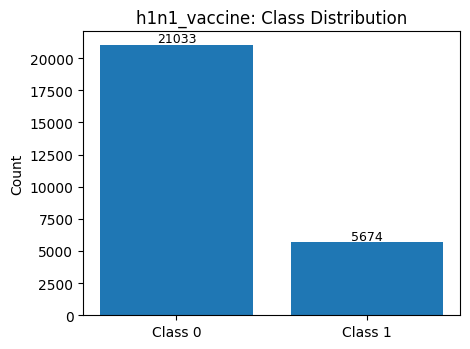

Class ratio (neg:pos) = 21033:5674  →  Suggested scale_pos_weight ≈ 3.71


In [14]:
# ------------------------
# Visualize class distribution
# ------------------------
counts = y.value_counts().sort_index()
neg, pos = int(counts.get(0, 0)), int(counts.get(1, 0))
pos_weight = neg / max(pos, 1)  # avoid division by zero

plt.figure(figsize=(4.8, 3.6))
plt.bar(["Class 0", "Class 1"], [neg, pos])
plt.title(f"{TARGET}: Class Distribution")
plt.ylabel("Count")
for i, v in enumerate([neg, pos]):
    plt.text(i, v + max(neg, pos)*0.01, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Class ratio (neg:pos) = {neg}:{pos}  →  Suggested scale_pos_weight ≈ {pos_weight:.2f}")


In [15]:
# ------------------------
# Cross-validation evaluator
# ------------------------
def cv_oof_eval(model: LGBMClassifier, X: pd.DataFrame, y: pd.Series, n_splits=5, seed=RANDOM_STATE):
    """
    Trains model with StratifiedKFold CV, returns:
      - OOF probabilities (for threshold tuning)
      - Fold-wise and global metrics at default threshold=0.5
    Uses LightGBM callbacks for version-safe early stopping.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof_prob = np.zeros(len(y), dtype=float)

    fold_metrics = []
    for fold, (tr, va) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]

        # ---- Early stopping via callbacks (works across LightGBM versions)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        prob = model.predict_proba(X_va)[:, 1]
        pred = (prob >= 0.5).astype(int)
        oof_prob[va] = prob

        fold_metrics.append({
            "fold": fold,
            "accuracy": accuracy_score(y_va, pred),
            "precision": precision_score(y_va, pred, zero_division=0),
            "recall": recall_score(y_va, pred, zero_division=0),
            "f1": f1_score(y_va, pred, zero_division=0),
            "auc": roc_auc_score(y_va, prob),
            "best_iteration_": getattr(model, "best_iteration_", None),
        })

    # ---- Aggregate metrics at threshold=0.5 using OOF predictions
    oof_pred = (oof_prob >= 0.5).astype(int)
    summary = {
        "accuracy": accuracy_score(y, oof_pred),
        "precision": precision_score(y, oof_pred, zero_division=0),
        "recall": recall_score(y, oof_pred, zero_division=0),
        "f1": f1_score(y, oof_pred, zero_division=0),
        "auc": roc_auc_score(y, oof_prob),
    }
    return np.array(oof_prob), pd.DataFrame(fold_metrics), summary


In [16]:
# ------------------------
# Base parameters
# Keep them moderate; early stopping will control rounds.
# ------------------------
base_params = dict(
    objective="binary",
    boosting_type="gbdt",
    random_state=RANDOM_STATE,
    n_estimators=1000,      # upper bound; early stopping will stop earlier
    learning_rate=0.03,
    num_leaves=31,
    max_depth=6,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    lambda_l1=0.5,
    lambda_l2=0.5,
)

# ---- Baseline model (no reweighting)
model_baseline = LGBMClassifier(**base_params)

# ---- Weighted model (handles imbalance in the loss)
# IMPORTANT: Use EITHER scale_pos_weight OR is_unbalance (not both).
model_weighted = LGBMClassifier(**base_params, scale_pos_weight=pos_weight)

model_baseline, model_weighted


(LGBMClassifier(bagging_fraction=0.8, feature_fraction=0.8, lambda_l1=0.5,
                lambda_l2=0.5, learning_rate=0.03, max_depth=6,
                n_estimators=1000, objective='binary', random_state=42),
 LGBMClassifier(bagging_fraction=0.8, feature_fraction=0.8, lambda_l1=0.5,
                lambda_l2=0.5, learning_rate=0.03, max_depth=6,
                n_estimators=1000, objective='binary', random_state=42,
                scale_pos_weight=3.706908706379979))

In [ ]:
# ------------------------
# Evaluate both settings (threshold=0.5)
# ------------------------
print("Evaluating baseline...")
oof_base, folds_base, summary_base = cv_oof_eval(model_baseline, X, y)

print("Evaluating weighted (scale_pos_weight)...")
oof_weight, folds_weight, summary_weight = cv_oof_eval(model_weighted, X, y)

In [19]:
# ---- Show fold tables
print("\nBaseline (per-fold):")
display(folds_base)

print("\nWeighted (per-fold):")
display(folds_weight)


Baseline (per-fold):


,fold,accuracy,precision,recall,f1,auc,best_iteration_
0,1,0.852490,0.733513,0.480176,0.580405,0.869389,184
1,2,0.858480,0.747712,0.503965,0.602105,0.875862,212
2,3,0.857517,0.734003,0.515873,0.605904,0.868223,250
3,4,0.858079,0.745124,0.504846,0.601891,0.870794,297
4,5,0.851900,0.718274,0.498678,0.588664,0.863115,244



Weighted (per-fold):


,fold,accuracy,precision,recall,f1,auc,best_iteration_
0,1,0.830026,0.589441,0.659031,0.622296,0.860737,40
1,2,0.829090,0.584733,0.674890,0.626585,0.868606,39
2,3,0.837671,0.615186,0.628748,0.621893,0.857268,33
3,4,0.825875,0.579643,0.657269,0.616020,0.860286,40
4,5,0.833739,0.610366,0.601762,0.606034,0.849736,33


In [20]:
# ---- Summary comparison at threshold 0.5
df_cmp_05 = pd.DataFrame([
    {"Model": "Baseline", **summary_base},
    {"Model": "Weighted", **summary_weight},
]).set_index("Model")

print("\n=== CV OOF Summary @ threshold=0.5 ===")
display(df_cmp_05.style.format("{:.3f}"))


=== CV OOF Summary @ threshold=0.5 ===


,accuracy,precision,recall,f1,auc
Model,,,,,
Baseline,0.856,0.736,0.501,0.596,0.869
Weighted,0.831,0.595,0.644,0.619,0.859
